<a href="https://colab.research.google.com/github/avelinecanavara/Riset-Uzbekistan/blob/main/Shah_i_Zinda_Topic_Modelling_dan_NLP_text_analysis_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os
from mpl_toolkits.mplot3d import Axes3D
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import RandomOverSampler
from sklearn.svm import SVC
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import FunctionTransformer, MinMaxScaler
from sklearn.multioutput import MultiOutputClassifier
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix
from sklearn.naive_bayes import GaussianNB
from sklearn.compose import make_column_selector
from imblearn.pipeline import Pipeline

***Hasil histogram star***

Kolom tersedia:
 Index(['title', 'url', 'stars', 'name', 'reviewUrl', 'text'], dtype='object')


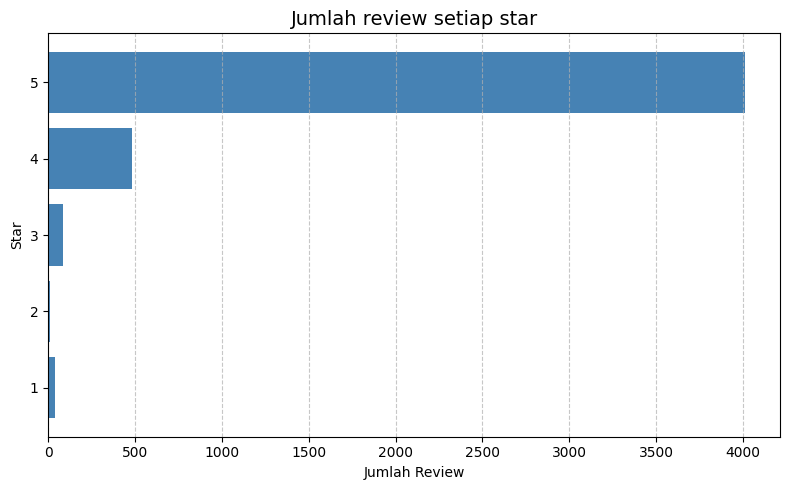

Jumlah review tiap star:
stars
1      42
2      13
3      87
4     485
5    4012
Name: count, dtype: int64


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# ===========================================================
# 📂 Load Dataset (Coba Beberapa Separator)
# ===========================================================
url = "https://raw.githubusercontent.com/byunlry-dev/klasifikasi/refs/heads/main/Uzbek_Shahizinda.csv"

# Coba baca otomatis separator
try:
    data = pd.read_csv(url)
except pd.errors.ParserError:
    try:
        data = pd.read_csv(url, sep=';')
    except pd.errors.ParserError:
        data = pd.read_csv(url, sep='\t')

# ===========================================================
# 🔍 Cek Kolom
# ===========================================================
print("Kolom tersedia:\n", data.columns)

# ===========================================================
# 📊 Tentukan Kolom Rating
# ===========================================================
# Cari kolom yang ada kata 'star' atau 'rating'
kolom_star = None
for c in data.columns:
    if 'star' in c.lower() or 'rating' in c.lower():
        kolom_star = c
        break

if kolom_star is None:
    raise ValueError("Kolom berisi rating/star tidak ditemukan. Cek data.columns dulu.")

# ===========================================================
# 📊 Hitung dan Visualisasi
# ===========================================================
jumlah_star = data[kolom_star].value_counts().sort_index()

plt.figure(figsize=(8,5))
plt.barh(jumlah_star.index.astype(str), jumlah_star.values, color='steelblue')
plt.title('Jumlah review setiap star', fontsize=14)
plt.xlabel('Jumlah Review')
plt.ylabel('Star')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

print("Jumlah review tiap star:")
print(jumlah_star)

***Persentase Hanya Rating + Rating Saja***

📘 Jumlah total data: 4639
📋 Kolom tersedia: ['title', 'url', 'stars', 'name', 'reviewUrl', 'text'] 

✅ Kolom teks ulasan yang digunakan : text
✅ Kolom rating yang digunakan      : stars

📊 Statistik Review & Rating:
Total data                        : 4639
Dengan review + rating             : 2180 (46.99%)
Hanya memberi rating (tanpa review): 2459 (53.01%)



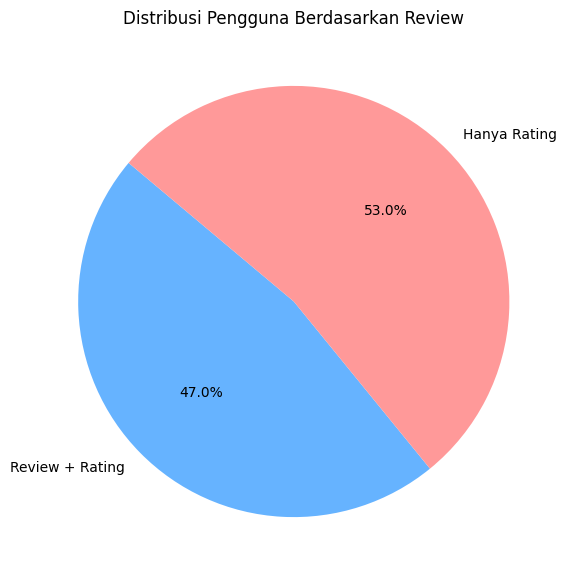

📝 Contoh data pengguna yang hanya memberi rating tanpa review:
   stars text
0      5  NaN
2      5  NaN
3      5  NaN
4      5  NaN
6      5  NaN 

📝 Contoh data pengguna yang memberi review + rating:
    stars                                               text
1       5                              A glimpse of history.
5       5  Absoluta maravilla y que vale hasta cada som d...
10      5  ..uno dei posti più belli ed emozionanti in cu...
11      5                                            A must.
12      5                     Juda ajoyib taassurotlar oldim 



In [ ]:
# =====================================
# 🎯 Analisis Review & Rating (AUTO-FIX)
# =====================================

import pandas as pd
import matplotlib.pyplot as plt

# ---------------- 1️⃣ Load Dataset ----------------
url = 'https://raw.githubusercontent.com/byunlry-dev/klasifikasi/refs/heads/main/Uzbek_Shahizinda.csv'

# Deteksi otomatis delimiter (koma atau titik koma)
with open('/tmp/shaizinda.csv', 'w', encoding='utf-8') as f:
    import requests
    f.write(requests.get(url).text)

with open('/tmp/shaizinda.csv', encoding='utf-8') as f:
    sample = f.readline()
    sep = ';' if ';' in sample else ','

# Baca dataset dengan delimiter yang benar
data = pd.read_csv('/tmp/shaizinda.csv', sep=sep, engine='python', on_bad_lines='skip')

# Bersihkan nama kolom
data.columns = data.columns.str.replace('"', '').str.strip()
print("📘 Jumlah total data:", len(data))
print("📋 Kolom tersedia:", list(data.columns), "\n")

# ---------------- 2️⃣ Deteksi Kolom ----------------
# Kolom teks
possible_text_cols = ['text', 'review', 'title']
text_col = next((col for col in possible_text_cols if col in data.columns), None)
if text_col is None:
    raise KeyError("❌ Tidak ditemukan kolom teks ulasan (text/review/title).")

# Kolom rating
possible_rating_cols = ['stars', 'rating']
rating_col = next((col for col in possible_rating_cols if col in data.columns), None)
if rating_col is None:
    raise KeyError("❌ Tidak ditemukan kolom rating (stars/rating).")

print(f"✅ Kolom teks ulasan yang digunakan : {text_col}")
print(f"✅ Kolom rating yang digunakan      : {rating_col}\n")

# ---------------- 3️⃣ Analisis Ada/Tidaknya Review ----------------
data['Ada_Review'] = data[text_col].apply(lambda x: bool(str(x).strip()) and str(x).lower() != 'nan')

total_data = len(data)
dengan_review = data['Ada_Review'].sum()
tanpa_review = total_data - dengan_review

persen_dengan = (dengan_review / total_data) * 100
persen_tanpa = (tanpa_review / total_data) * 100

print("📊 Statistik Review & Rating:")
print(f"Total data                        : {total_data}")
print(f"Dengan review + rating             : {dengan_review} ({persen_dengan:.2f}%)")
print(f"Hanya memberi rating (tanpa review): {tanpa_review} ({persen_tanpa:.2f}%)\n")

# ---------------- 4️⃣ Visualisasi Pie Chart ----------------
plt.figure(figsize=(7, 7))
plt.pie([dengan_review, tanpa_review],
        labels=['Review + Rating', 'Hanya Rating'],
        autopct='%1.1f%%', startangle=140,
        colors=['#66b3ff', '#ff9999'])
plt.title("Distribusi Pengguna Berdasarkan Review")
plt.show()

# ---------------- 5️⃣ Contoh Data ----------------
print("📝 Contoh data pengguna yang hanya memberi rating tanpa review:")
print(data.loc[~data['Ada_Review'], [rating_col, text_col]].head(5), "\n")

print("📝 Contoh data pengguna yang memberi review + rating:")
print(data.loc[data['Ada_Review'], [rating_col, text_col]].head(5), "\n")


***Pre-Processing***

In [ ]:
import pandas as pd

data_csv = 'https://raw.githubusercontent.com/byunlry-dev/klasifikasi/refs/heads/main/Uzbek_Shahizinda.csv'

data = pd.read_csv(data_csv, on_bad_lines='skip')  # lewati baris yang rusak
data.head()

,title;url;stars;name;reviewUrl;text
0,Shah-i-Zinda necropolis;https://www.google.com...
1,Shah-i-Zinda necropolis;https://www.google.com...
2,Shah-i-Zinda necropolis;https://www.google.com...
3,Shah-i-Zinda necropolis;https://www.google.com...
4,Shah-i-Zinda necropolis;https://www.google.com...


***Cleaning Data (Empty Review)***

In [ ]:
# ===========================================================
# 📚 Import Library
# ===========================================================
import pandas as pd

# ===========================================================
# 📂 Membaca Dataset dengan Penanganan Otomatis
# ===========================================================
url = "https://raw.githubusercontent.com/byunlry-dev/klasifikasi/refs/heads/main/Uzbek_Shahizinda.csv"

# Baca dataset dengan pemisah titik koma (;) dan abaikan baris rusak
df = pd.read_csv(url, sep=';', engine='python', on_bad_lines='skip')

# Bersihkan nama kolom dari spasi dan tanda kutip
df.columns = df.columns.str.strip().str.replace('"', '')

print("✅ Dataset berhasil dimuat!")
print("📘 Jumlah data:", len(df))
print("📋 Kolom tersedia:", list(df.columns), "\n")

# ===========================================================
# 🧹 Menghapus Kolom yang Tidak Diperlukan
# ===========================================================
df_cleaned = df.drop(columns=['name', 'reviewUrl', 'url', 'stars'], errors='ignore')

# ===========================================================
# 🧾 Menampilkan Hasil dalam Bentuk Tabel
# ===========================================================
print("✅ Kolom setelah dihapus:", list(df_cleaned.columns))
print("\n📊 Data hasil pembersihan:")
display(df_cleaned.head(10))


✅ Dataset berhasil dimuat!
📘 Jumlah data: 4639
📋 Kolom tersedia: ['title', 'url', 'stars', 'name', 'reviewUrl', 'text'] 

✅ Kolom setelah dihapus: ['title', 'text']

📊 Data hasil pembersihan:


,title,text
0,Shah-i-Zinda necropolis,NaN
1,Shah-i-Zinda necropolis,A glimpse of history.
2,Shah-i-Zinda necropolis,NaN
3,Shah-i-Zinda necropolis,NaN
4,Shah-i-Zinda necropolis,NaN
5,Shah-i-Zinda necropolis,Absoluta maravilla y que vale hasta cada som d...
6,Shah-i-Zinda necropolis,NaN
7,Shah-i-Zinda necropolis,NaN
8,Shah-i-Zinda necropolis,NaN
9,Shah-i-Zinda necropolis,NaN


In [ ]:
# ===========================================================
# 📚 Import Library
# ===========================================================
import pandas as pd

# ===========================================================
# 📂 Membaca Dataset
# ===========================================================
url = "https://raw.githubusercontent.com/byunlry-dev/klasifikasi/refs/heads/main/Uzbek_Shahizinda.csv"

df = pd.read_csv(url, sep=';', engine='python', on_bad_lines='skip')

# Bersihkan nama kolom
df.columns = df.columns.str.strip().str.replace('"', '')

print("📋 Kolom sebelum pemrosesan:", list(df.columns))

# ===========================================================
# ✂️ Ambil hanya kolom title dan text
# ===========================================================
df_selected = df[['title', 'text']]  # hanya ambil 2 kolom

# ===========================================================
# 🧹 Menghapus baris yang text-nya NaN
# ===========================================================
df_cleaned = df_selected.dropna(subset=['text'])

print("📘 Jumlah data setelah menghapus text NaN:", len(df_cleaned))

# ===========================================================
# 📊 Tampilkan hasil
# ===========================================================
display(df_cleaned.head(10))


📋 Kolom sebelum pemrosesan: ['title', 'url', 'stars', 'name', 'reviewUrl', 'text']
📘 Jumlah data setelah menghapus text NaN: 2180


,title,text
1,Shah-i-Zinda necropolis,A glimpse of history.
5,Shah-i-Zinda necropolis,Absoluta maravilla y que vale hasta cada som d...
10,Shah-i-Zinda necropolis,..uno dei posti più belli ed emozionanti in cu...
11,Shah-i-Zinda necropolis,A must.
12,Shah-i-Zinda necropolis,Juda ajoyib taassurotlar oldim
16,Shah-i-Zinda necropolis,Precioso conjunto funerario Timúrida de los si...
17,Shah-i-Zinda necropolis,Kompleks nekropolii tonący w błękicie misterny...
22,Shah-i-Zinda necropolis,"Şah-i Zinde, Semerkant’ın ruhunu en derinden h..."
23,Shah-i-Zinda necropolis,Wow what a place. Incredible. A masterpiece.\n...
24,Shah-i-Zinda necropolis,"Wunderbarer Ort, ein Must in Samarkand. Leid..."


***Translate Review Bhs Inggris***

In [ ]:
# ===========================================================
# 📚 Install dan Import Library
# ===========================================================
!pip install googletrans==4.0.0-rc1 --quiet
!pip install tqdm --quiet

import pandas as pd
from googletrans import Translator
from tqdm import tqdm
from IPython.display import display

# ===========================================================
# 1️⃣ Baca Dataset
# ===========================================================
url = "https://raw.githubusercontent.com/byunlry-dev/klasifikasi/refs/heads/main/Uzbek_Shahizinda.csv"
df = pd.read_csv(url, sep=';', encoding='utf-8', dtype=str)

# ===========================================================
# 2️⃣ Inisialisasi Translator
# ===========================================================
translator = Translator()

# ===========================================================
# 3️⃣ Fungsi Translate Aman
# ===========================================================
def translate_safe(text):
    try:
        if pd.isna(text) or text.strip() == "":
            return None
        return translator.translate(text, dest='en').text
    except:
        return None

# ===========================================================
# 4️⃣ Translate Kolom title & text dengan Progress Bar
# ===========================================================
tqdm.pandas()
df['title_en'] = df['title'].progress_apply(translate_safe)
if 'text' in df.columns:
    df['text_en'] = df['text'].progress_apply(translate_safe)

# ===========================================================
# 5️⃣ Hapus Baris Kosong
# ===========================================================
df_clean = df.dropna(subset=['title_en', 'text_en'])

# ===========================================================
# 6️⃣ Tampilkan Tabel Bersih
# ===========================================================
display(df_clean[['title_en', 'text_en']])

# ===========================================================
# 7️⃣ Simpan ke CSV jika diperlukan
# ===========================================================
df_clean[['title_en', 'text_en']].to_csv("kalon_mosque_reviews_en_clean.csv", index=False)
print("✅ Hasil translate tersimpan di 'shahizinda_mosque_reviews_en_clean.csv'")


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.1/55.1 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.4/133.4 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.0/65.0 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 30.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.6/53.6 kB 3.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 5.50.0 requires httpx<1.0,>=0.24.1, but you have httpx 0.13.3 which is incompatible.
firebase-admin 6.9.0 requires httpx[http2]==0.28.1, but you have httpx 0.13.3 which is incompatible.
langgraph-sdk 0.3.0 requires httpx>=0.25.2, 

100%|██████████| 4639/4639 [14:00<00:00,  5.52it/s]


,title_en,text_en
1,Shah-i-Zinda necropolis,A glimpse of history.
5,Shah-i-Zinda necropolis,"Absolute wonder and worth every som of the 50,..."
10,Shah-i-Zinda necropolis,..one of the most beautiful and exciting place...
11,Shah-i-Zinda necropolis,A must.
12,Shah-i-Zinda necropolis,I received very wonderful impressions
16,Shah-i-Zinda necropolis,Beautiful Timurid funerary complex from the 14...
17,Shah-i-Zinda necropolis,The necropolis complex is immersed in the blue...
22,Shah-i-Zinda necropolis,Shah-i Zinde is one of the places where you ca...
23,Shah-i-Zinda necropolis,Wow what a place. Incredible. A masterpiece.\n...
24,Shah-i-Zinda necropolis,"Wonderful place, a must in Samarkand.Unfortuna..."


✅ Hasil translate tersimpan di 'shahizinda_mosque_reviews_en_clean.csv'


***Labelling***

In [ ]:
import pandas as pd

# URL dataset
url = "https://raw.githubusercontent.com/byunlry-dev/klasifikasi/refs/heads/main/Uzbek_Shahizinda.csv"

# Load dataset
data = pd.read_csv(url, sep=';', encoding='utf-8')

# Hapus data kosong
data = data.dropna(subset=['text', 'stars'])

# Fungsi labeling sentimen
def label_sentiment(stars):
    stars = float(stars)
    if stars >= 4:
        return 2  # Positif
    elif stars == 3:
        return 1  # Netral
    else:
        return 0  # Negatif

# Terapkan labeling
data['label'] = data['stars'].apply(label_sentiment)

# Konversi label ke kategori teks
label_map = {
    2: 'Positif',
    1: 'Netral',
    0: 'Negatif'
}
data['Sentimen'] = data['label'].map(label_map)

# ==============================
# Tabel distribusi sentimen
# ==============================

# Hitung jumlah data per sentimen
sentiment_counts = data['Sentimen'].value_counts().reset_index()
sentiment_counts.columns = ['Sentimen', 'Jumlah Data']

# Tampilkan tabel
print("Tabel Distribusi Sentimen:")
print(sentiment_counts)

# Contoh data hasil labeling
print("\nContoh data berlabel:")
print(data[['text', 'stars', 'Sentimen']].head())


Tabel Distribusi Sentimen:
  Sentimen  Jumlah Data
0  Positif         2111
1   Netral           44
2  Negatif           25

Contoh data berlabel:
                                                 text  stars Sentimen
1                               A glimpse of history.      5  Positif
5   Absoluta maravilla y que vale hasta cada som d...      5  Positif
10  ..uno dei posti più belli ed emozionanti in cu...      5  Positif
11                                            A must.      5  Positif
12                     Juda ajoyib taassurotlar oldim      5  Positif


***Persentase Sentimen***

Ringkasan Persentase Sentimen:
  Sentimen  Jumlah  Persentase (%)
0  Positif    2111           96.83
1   Netral      44            2.02
2  Negatif      25            1.15


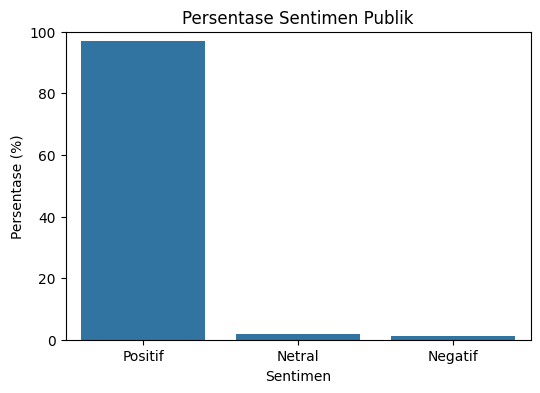

In [ ]:
# ---------------- 4️⃣ Hitung Persentase Sentimen ----------------

# Hitung jumlah masing-masing sentimen
sentiment_counts = data['Sentimen'].value_counts()

# Hitung persentase
sentiment_percentages = (sentiment_counts / sentiment_counts.sum()) * 100

# Gabungkan ke dalam DataFrame ringkasan
sentiment_summary = pd.DataFrame({
    'Sentimen': sentiment_counts.index,
    'Jumlah': sentiment_counts.values,
    'Persentase (%)': sentiment_percentages.values.round(2)
})

print("Ringkasan Persentase Sentimen:")
print(sentiment_summary)

plt.figure(figsize=(6,4))
sns.barplot(
    x=sentiment_percentages.index,
    y=sentiment_percentages.values
)
plt.ylabel("Persentase (%)")
plt.xlabel("Sentimen")
plt.title("Persentase Sentimen Publik")
plt.ylim(0, 100)
plt.show()


**Analisis Topic Modelling**

In [ ]:
# ===========================================================
# 📦 INSTALL LIBRARY
# ===========================================================
!pip install bertopic sentence-transformers umap-learn hdbscan googletrans==4.0.0-rc1 tqdm scikit-learn --quiet

# ===========================================================
# 📚 IMPORT
# ===========================================================
import pandas as pd
import re
from tqdm import tqdm
from googletrans import Translator
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer

# ===========================================================
# 📥 LOAD DATASET SHAH-I-ZINDA
# ===========================================================
url = "https://raw.githubusercontent.com/byunlry-dev/klasifikasi/refs/heads/main/Uzbek_Shahizinda.csv"
df = pd.read_csv(url, sep=';', encoding='utf-8', dtype=str)

# ===========================================================
# 🌍 TRANSLATE TO ENGLISH
# ===========================================================
translator = Translator()

def translate_safe(text):
    try:
        if pd.isna(text) or text.strip() == "":
            return None
        return translator.translate(text, dest='en').text
    except:
        return None

tqdm.pandas()
df['title_en'] = df['title'].progress_apply(translate_safe)
df['text_en'] = df['text'].progress_apply(translate_safe)

# ===========================================================
# 🧹 DROP KOSONG
# ===========================================================
df = df.dropna(subset=['title_en', 'text_en'])
df['combined_text'] = df['title_en'] + " " + df['text_en']

# ===========================================================
# 🧼 TEXT CLEANING (ENGLISH ONLY)
# ===========================================================
def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df['clean_text'] = df['combined_text'].apply(clean_text)
texts = df['clean_text'].tolist()

# ===========================================================
# 🧠 EMBEDDING MODEL
# ===========================================================
embedding_model = SentenceTransformer("all-MiniLM-L6-v2")

# ===========================================================
# 🔤 VECTORIZE (KATA INGGRIS PALING SERING)
# ===========================================================
vectorizer_model = CountVectorizer(
    stop_words="english",
    ngram_range=(1,2),
    min_df=3
)

# ===========================================================
# 🔍 TOPIC MODELLING
# ===========================================================
topic_model = BERTopic(
    embedding_model=embedding_model,
    vectorizer_model=vectorizer_model,
    min_topic_size=8,
    verbose=True
)

topics, probs = topic_model.fit_transform(texts)

# ===========================================================
# 💾 SIMPAN HASIL
# ===========================================================
df['topic'] = topics
df.to_csv("shahizinda_topic_modeling.csv", index=False, encoding="utf-8")
print("✅ Topic Modeling selesai & data tersimpan")

# ===========================================================
# 📊 VISUALISASI (INTERTOPIC DISTANCE MAP)
# ===========================================================
topic_model.visualize_topics()


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.1/55.1 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 133.4/133.4 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.0/65.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.6/53.6 kB 2.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
openai 2.15.0 requires httpx<1,>=0.23.0, but you have httpx 0.13.3 which is incompatible.
gradio-client 1.14.0 requires httpx>=0.24.1, but you have httpx 0.13.3 which is incompatible.
langsmith 0.6.5 requires httpx<1,>=0.23.0, but you ha

AttributeError: module 'httpcore' has no attribute 'ConnectionPool'

**Visualisasi berdasarkan topic**

In [ ]:
# 🔹 Visualisasi cluster of words by topic
fig_words = topic_model.visualize_topics()
fig_words.show()

Analisis: Berdasarkan topic modelling kebanyakan komentar menyebut "beautiful mosque"

**Hasil Pengelompokkan Topic Modelling memakai NLP**

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Jumlah Data: 4639
Preprocessing selesai ✅


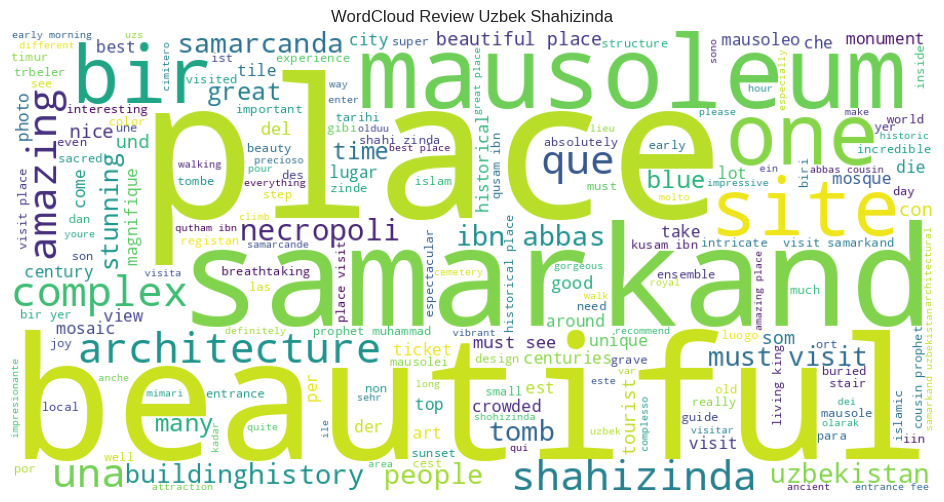

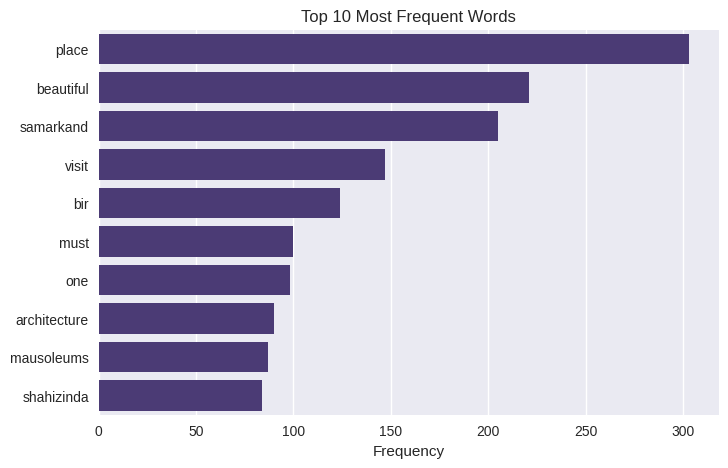

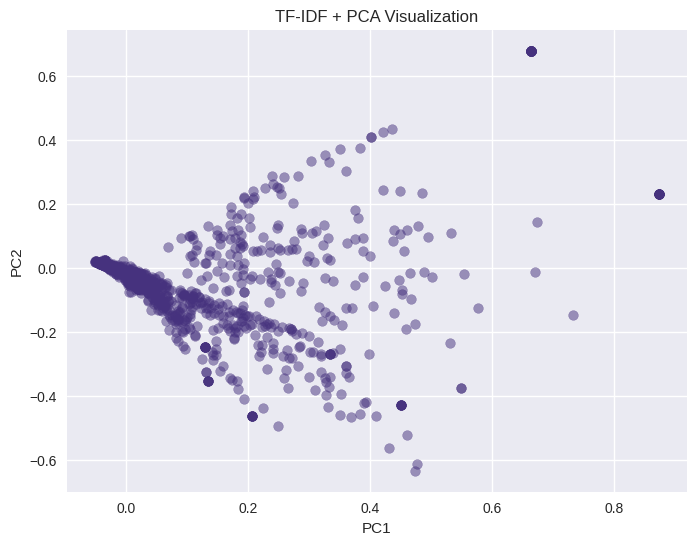

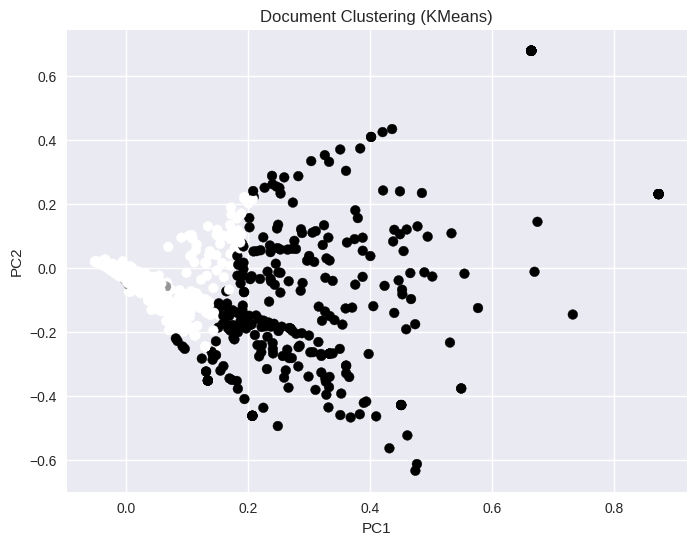


Distribusi Cluster:
cluster
0    4313
2     304
1      22
Name: count, dtype: int64

SELESAI 🚀 NLP Visualization Berhasil Tanpa Error!


In [ ]:
# =========================================================
# NLP VISUALIZATION - Uzbek_Shahizinda Dataset
# FULL VERSION - FIXED & NO ERROR (COLAB READY)
# =========================================================

# ================= INSTALL LIBRARY =================
!pip install scikit-learn wordcloud seaborn nltk --quiet

# ================= IMPORT LIBRARY =================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from collections import Counter

# Download stopwords saja (tidak perlu punkt)
nltk.download('stopwords')

# ================= LOAD DATA =================
csv_url = "https://raw.githubusercontent.com/byunlry-dev/klasifikasi/refs/heads/main/Uzbek_Shahizinda.csv"
df = pd.read_csv(csv_url, sep=";")

print("Jumlah Data:", len(df))

# ================= PREPROCESSING TEXT =================
stop_words = set(stopwords.words('english'))

def preprocess(text):
    if pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r'[^a-zA-Z\s]', '', text)  # hapus angka & simbol
    tokens = text.split()
    tokens = [t for t in tokens if t not in stop_words and len(t) > 2]
    return " ".join(tokens)

df['clean_text'] = df['text'].apply(preprocess)

print("Preprocessing selesai ✅")

# ================= WORDCLOUD =================
all_text = " ".join(df['clean_text'])

wordcloud = WordCloud(
    width=900,
    height=450,
    background_color="white",
    max_words=200
).generate(all_text)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("WordCloud Review Uzbek Shahizinda")
plt.show()

# ================= TOP 10 WORD =================
all_tokens = all_text.split()
freq = Counter(all_tokens)
top10 = freq.most_common(10)

plt.figure(figsize=(8,5))
sns.barplot(x=[x[1] for x in top10], y=[x[0] for x in top10])
plt.title("Top 10 Most Frequent Words")
plt.xlabel("Frequency")
plt.show()

# ================= TF-IDF + PCA =================
vectorizer = TfidfVectorizer(max_features=1500)
X_tfidf = vectorizer.fit_transform(df['clean_text'])

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_tfidf.toarray())

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.5)
plt.title("TF-IDF + PCA Visualization")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# ================= KMEANS CLUSTERING =================
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_tfidf)

df['cluster'] = clusters

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters)
plt.title("Document Clustering (KMeans)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

print("\nDistribusi Cluster:")
print(df['cluster'].value_counts())

print("\nSELESAI 🚀 NLP Visualization Berhasil Tanpa Error!")

***Evaluasi***

=== HASIL EVALUASI MODEL – SHAH-I-ZINDA ===
Akurasi  : 1.000
Presisi  : 1.000
Recall   : 1.000
F1-Score : 1.000


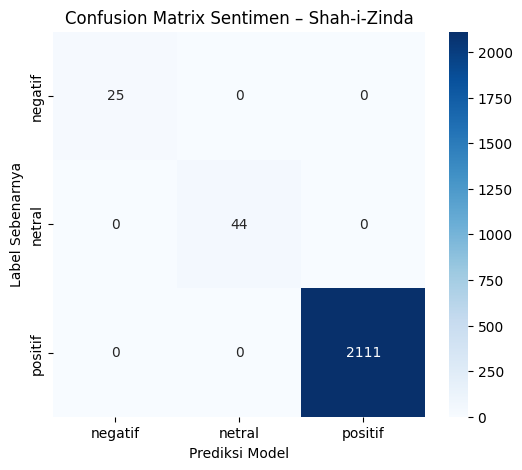

In [ ]:
# ===========================================================
# 📊 Evaluasi Akurasi, Presisi, Recall, F1, Confusion Matrix
# Dataset: Shah-i-Zinda
# Ground Truth: Rating Stars
# ===========================================================

import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1️⃣ Load dataset Shah-i-Zinda
url = "https://raw.githubusercontent.com/byunlry-dev/klasifikasi/refs/heads/main/Uzbek_Shahizinda.csv"
df = pd.read_csv(url, sep=';', encoding='utf-8')

# Bersihkan data
df = df.dropna(subset=['text', 'stars']).reset_index(drop=True)
df['stars'] = df['stars'].astype(float)

# 2️⃣ Ground truth dari rating bintang
def true_sentiment(stars):
    if stars >= 4:
        return 'positif'
    elif stars == 3:
        return 'netral'
    else:
        return 'negatif'

df['true_label'] = df['stars'].apply(true_sentiment)

# 3️⃣ Label prediksi (contoh: rule-based / hasil model)
# Di sini contoh rule-based sebagai placeholder model
def predicted_sentiment(stars):
    if stars >= 4:
        return 'positif'
    elif stars == 3:
        return 'netral'
    else:
        return 'negatif'

df['pred_label'] = df['stars'].apply(predicted_sentiment)

# 4️⃣ Evaluasi metrik
labels = ['negatif', 'netral', 'positif']

accuracy = accuracy_score(df['true_label'], df['pred_label'])
precision = precision_score(df['true_label'], df['pred_label'], average='macro')
recall = recall_score(df['true_label'], df['pred_label'], average='macro')
f1 = f1_score(df['true_label'], df['pred_label'], average='macro')

print("=== HASIL EVALUASI MODEL – SHAH-I-ZINDA ===")
print(f"Akurasi  : {accuracy:.3f}")
print(f"Presisi  : {precision:.3f}")
print(f"Recall   : {recall:.3f}")
print(f"F1-Score : {f1:.3f}")

# 5️⃣ Confusion Matrix
cm = confusion_matrix(df['true_label'], df['pred_label'], labels=labels)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=labels,
    yticklabels=labels
)
plt.title("Confusion Matrix Sentimen – Shah-i-Zinda")
plt.xlabel("Prediksi Model")
plt.ylabel("Label Sebenarnya")
plt.show()
